NOTE - This notebook may not be fully updated. See part 999 to see my final player comparison preparation.

In this notebook we will pick the best version of each model, and compare then with each other. We will also see which statistics correlate to higher inaccuracies.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import pandas as pd
import numpy as np

# Adjustable parameters for adjusted score
alpha, beta = 2, 2

# Load main player data
mlb_players = pd.read_csv('All Pitchers Cleaned.csv')

# Load model results
results_dtree = pd.read_csv('stored_results/Results_DTree_GS_Best_F1_Standard_KFold.csv')
results_etc = pd.read_csv('stored_results/Results_ETC_GS_Best_F1_Standard_KFold.csv')
results_logreg = pd.read_csv('stored_results/Results_Logreg_no_GS.csv')
results_rfc = pd.read_csv('stored_results/Results_RFC_GS_Best_F1_Standard_KFold.csv')
results_nn = pd.read_csv('stored_results/Results_Neural_Network_1.csv')

# Organize all models dynamically
model_dfs = {
    "Decision Tree": results_dtree,
    "Extra Trees": results_etc,
    "Logistic Regression": results_logreg,
    "Random Forest": results_rfc,
    "Neural Network": results_nn
}

# Store all player scores across models
player_scores = []

for model_name, df in model_dfs.items():
    # Skip models missing confidence info
    if 'Prediction Confidence' not in df.columns:
        print(f"⚠️ Skipping {model_name}: No 'Prediction Confidence' column found.")
        continue

    # Add 'Prediction Correct' if missing
    if 'Prediction Correct' not in df.columns and {'Hall of Fame', 'Prediction'}.issubset(df.columns):
        df['Prediction Correct'] = (df['Hall of Fame'] == df['Prediction'])

    # Calculate adjusted score
    df['Adjusted Prediction Score'] = np.where(
        df['Prediction Correct'],
        df['Prediction Confidence'] ** alpha,
        -beta * (df['Prediction Confidence'] ** alpha)
    )

    # Keep only relevant columns for aggregation
    model_data = df[['Player', 'Prediction Correct', 'Adjusted Prediction Score']].copy()
    model_data['Model'] = model_name
    player_scores.append(model_data)

# Combine results from all models
all_scores = pd.concat(player_scores, ignore_index=True)

# --- Calculate player-level metrics ---
player_metrics = (
    all_scores.groupby('Player')
    .agg(
        Accuracy_Percent=('Prediction Correct', lambda x: 100 * x.mean()),
        Avg_Adjusted_Score=('Adjusted Prediction Score', 'mean')
    )
    .reset_index()
)




# --- Merge metrics into main dataset ---
mlb_players = mlb_players.merge(player_metrics, on='Player', how='left')

mlb_players.rename(columns={'Accuracy_Percent': 'Percent of Predictions Accurate'}, inplace=True)
mlb_players.rename(columns={'Avg_Adjusted_Score': 'Mean Adjusted Prediction Score'}, inplace=True)


# --- (Optional) Save updated model files with adjusted scores ---
#for model_name, df in model_dfs.items():
#    out_path = f"stored_results/{model_name.replace(' ', '_')}_with_AdjustedScore.csv"
#    df.to_csv(out_path, index=False)

# Preview results
mlb_players

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame,Percent of Predictions Accurate,Mean Adjusted Prediction Score
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1,100.0,0.960245
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1,100.0,0.624223
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1,100.0,0.894218
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1,100.0,0.780986
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1,100.0,0.867892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0,100.0,0.799945
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0,100.0,0.799977
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0,100.0,0.799953
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0,100.0,0.799880


In [16]:
mlb_players.nsmallest(10, 'Mean Adjusted Prediction Score')

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame,Percent of Predictions Accurate,Mean Adjusted Prediction Score
15,Roger Clemens,1984,21,2007,44,23,354,184,0.658,538,...,3.09,1.173,7.7,0.7,2.9,8.6,2.96,0,0.0,-1.888336
72,Luis Tiant,1964,23,1982,41,18,229,172,0.571,401,...,3.47,1.199,7.9,0.9,2.8,6.2,2.19,0,0.0,-1.493853
105,Jesse Haines,1918,24,1937,43,19,210,158,0.571,368,...,3.82,1.350,9.7,0.5,2.4,2.8,1.13,1,0.0,-1.426095
986,Babe Ruth,1914,19,1935,40,21,94,46,0.671,140,...,2.81,1.159,7.2,0.1,3.2,3.6,1.11,1,0.0,-1.341166
30,Jack Powell,1897,22,1912,37,15,245,255,0.490,500,...,3.01,1.217,8.9,0.2,2.1,3.3,1.59,0,0.0,-1.328183
246,Lefty Gomez,1930,21,1943,34,13,189,102,0.649,291,...,3.87,1.352,8.2,0.5,3.9,5.3,1.34,1,0.0,-1.299672
91,Rube Marquard,1908,21,1925,38,17,201,177,0.532,378,...,2.89,1.237,8.8,0.3,2.3,4.3,1.86,1,0.0,-1.290795
152,Jack Chesbro,1899,25,1909,35,10,198,132,0.600,330,...,2.67,1.152,8.2,0.1,2.1,3.9,1.83,1,0.0,-1.185462
98,Curt Schilling,1988,21,2007,40,19,216,146,0.597,362,...,3.23,1.137,8.3,1.0,2.0,8.6,4.38,0,0.0,-1.162293
257,John Ward,1878,18,1894,34,16,164,103,0.614,267,...,2.43,1.043,8.5,0.1,0.9,3.4,3.64,1,0.0,-1.152310


In [26]:
mlb_pitchers_np = mlb_players.drop('Player', axis=1)
correlations = mlb_pitchers_np.corrwith(mlb_pitchers_np['Mean Adjusted Prediction Score'])

# Sort by absolute correlation
ranked_correlations = correlations.abs().sort_values(ascending=False)
ranked_correlations

Mean Adjusted Prediction Score     1.000000
Percent of Predictions Accurate    0.964270
Hall of Fame                       0.500346
Wins                               0.422295
Innings Pitched                    0.385099
Total Decisions                    0.384632
ERA+                               0.377816
BF                                 0.368532
Hits Allowed                       0.353681
Shutouts                           0.331908
Strikeouts                         0.326764
Win Percentage                     0.318061
Games Started                      0.306106
Runs Allowed                       0.305821
WHIP                               0.304378
Career Length                      0.302562
Earned Run Average                 0.298593
Complete Games                     0.296718
Losses                             0.296423
Earned Runs Allowed                0.279599
FIP                                0.277560
Total Games                        0.247908
Walks Allowed                   

We saw earlier that Relief Appearances had almost zero correlation with Hall of Fame selection. It turns out the same holds true for Prediction Score. Seems the models weren't sure what to do with it, and if it did steer their decisions, it wasn't likely to result in an error.

In fact, no single metric has an especially strong correlation with our Prediction Score.

# Player Lookup

In [28]:
mlb_players[mlb_players['Player'] == 'Mariano Rivera']

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame,Percent of Predictions Accurate,Mean Adjusted Prediction Score
923,Mariano Rivera,1995,25,2013,43,18,82,60,0.577,142,...,2.76,1.0,7.0,0.5,2.0,8.2,4.1,1,100.0,0.700501


# Splitting our dataset between confusion and non-confusing players

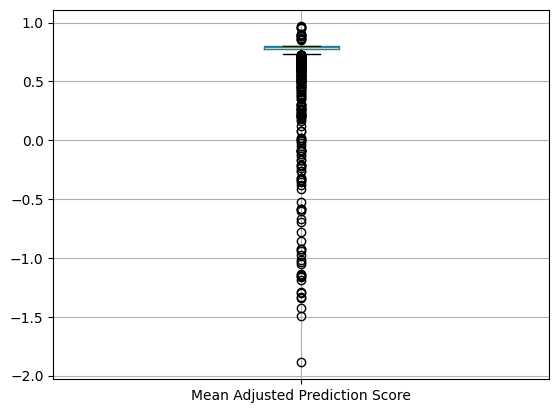

In [20]:
mlb_players.boxplot(column='Mean Adjusted Prediction Score')
plt.show()

In [24]:
mlb_players_minus_inaccurates = mlb_players[mlb_players['Mean Adjusted Prediction Score'] > -0.5]
mlb_players_minus_inaccurates

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame,Percent of Predictions Accurate,Mean Adjusted Prediction Score
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1,100.0,0.960245
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1,100.0,0.624223
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1,100.0,0.894218
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1,100.0,0.780986
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1,100.0,0.867892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0,100.0,0.799945
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0,100.0,0.799977
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0,100.0,0.799953
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0,100.0,0.799880


In [27]:
mlb_players_minus_inaccurates.nsmallest(10, 'Mean Adjusted Prediction Score')

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame,Percent of Predictions Accurate,Mean Adjusted Prediction Score
78,Joe McGinnity,1899,28,1908,37,9,246,142,0.634,388,...,3.04,1.188,8.6,0.1,2.1,2.8,1.32,1,20.0,-0.411648
74,John Smoltz,1988,21,2009,42,21,213,155,0.579,368,...,3.24,1.176,8.0,0.7,2.6,8.0,3.05,1,40.0,-0.379393
757,Ray Brown,1931,23,1945,37,14,119,46,0.721,165,...,2.77,1.226,8.5,0.2,2.5,4.4,1.73,1,40.0,-0.354752
534,Rich Gossage,1972,20,1994,42,22,124,107,0.537,231,...,3.18,1.232,7.4,0.6,3.6,7.5,2.05,1,60.0,-0.341045
915,Lee Smith,1980,22,1997,39,17,71,92,0.436,163,...,2.93,1.256,7.9,0.6,3.4,8.7,2.57,1,40.0,-0.340022
14,Bobby Mathews,1871,19,1887,35,16,297,248,0.545,545,...,2.70,1.237,10.2,0.1,1.0,2.8,2.87,0,60.0,-0.321897
82,Charlie Buffinton,1882,21,1892,31,10,233,152,0.605,385,...,3.08,1.234,8.8,0.2,2.3,4.5,1.99,0,40.0,-0.320169
44,Jack Quinn,1909,25,1933,49,24,247,218,0.531,465,...,3.08,1.300,9.7,0.2,2.0,3.1,1.55,0,60.0,-0.264824
297,Sandy Koufax,1955,19,1966,30,11,165,87,0.655,252,...,2.69,1.106,6.8,0.8,3.2,9.3,2.93,1,40.0,-0.257316
605,Rollie Fingers,1968,21,1985,38,17,114,118,0.491,232,...,2.96,1.156,7.8,0.7,2.6,6.9,2.64,1,60.0,-0.233861
